In [29]:
import os
import random
import json
import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image, ImageFilter
import numpy as np

from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

from pathlib import Path

CHECKPOINTS_DIR = Path("E:\Proyects Python based\ProyectoAvanzado2\models\Super-resolution\srgan2")
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


In [11]:
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    name: str
    scenario: str
    downsample: str
    blur_sigma: float
    noise: str
    scale: int
    lr_size: int

EXPERIMENTS = [
    ExperimentConfig("model_1", "A", "bicubic", 1.0, "gaussian", 2, 256),
    ExperimentConfig("model_2", "A", "bicubic", 1.0, "gaussian", 4, 128),
    ExperimentConfig("model_3", "A", "bicubic", 1.0, "gaussian", 8, 64),
    ExperimentConfig("model_4", "B", "bilinear", 1.5, "gaussian", 2, 256),
    ExperimentConfig("model_5", "B", "bilinear", 1.5, "gaussian", 4, 128),
    ExperimentConfig("model_6", "B", "bilinear", 1.5, "gaussian", 8, 64),
    ExperimentConfig("model_7", "C", "lanczos", 2.0, "poisson", 2, 256),
    ExperimentConfig("model_8", "C", "lanczos", 2.0, "poisson", 4, 128),
    ExperimentConfig("model_9", "C", "lanczos", 2.0, "poisson", 8, 64),
]

In [12]:
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    name: str
    scenario: str
    downsample: str
    blur_sigma: float
    noise: str
    scale: int
    lr_size: int

EXPERIMENTS = [
    ExperimentConfig("model_1", "A", "bicubic", 1.0, "gaussian", 2, 256),
    ExperimentConfig("model_2", "A", "bicubic", 1.0, "gaussian", 4, 128),
    ExperimentConfig("model_3", "A", "bicubic", 1.0, "gaussian", 8, 64),
    ExperimentConfig("model_4", "B", "bilinear", 1.5, "gaussian", 2, 256),
    ExperimentConfig("model_5", "B", "bilinear", 1.5, "gaussian", 4, 128),
    ExperimentConfig("model_6", "B", "bilinear", 1.5, "gaussian", 8, 64),
    ExperimentConfig("model_7", "C", "lanczos", 2.0, "poisson", 2, 256),
    ExperimentConfig("model_8", "C", "lanczos", 2.0, "poisson", 4, 128),
    ExperimentConfig("model_9", "C", "lanczos", 2.0, "poisson", 8, 64),
]

In [13]:
class SRDataset(Dataset):
    def __init__(self, image_paths, cfg, patch_size=128):
        self.image_paths = image_paths
        self.cfg = cfg
        self.patch_size = patch_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        # 🔥 Crop aleatorio
        w, h = img.size
        ps = self.patch_size
        x = random.randint(0, w - ps)
        y = random.randint(0, h - ps)

        hr = img.crop((x, y, x + ps, y + ps))

        # Blur
        hr = hr.filter(ImageFilter.GaussianBlur(self.cfg.blur_sigma))

        # Downsample
        if self.cfg.downsample == "bicubic":
            lr = hr.resize((ps // self.cfg.scale, ps // self.cfg.scale), Image.BICUBIC)
        elif self.cfg.downsample == "bilinear":
            lr = hr.resize((ps // self.cfg.scale, ps // self.cfg.scale), Image.BILINEAR)
        else:
            lr = hr.resize((ps // self.cfg.scale, ps // self.cfg.scale), Image.LANCZOS)

        # Noise
        lr_np = np.array(lr).astype(np.float32)

        if self.cfg.noise == "gaussian":
            lr_np += np.random.normal(0, 5, lr_np.shape)
        else:
            lr_np = np.random.poisson(lr_np)

        lr_np = np.clip(lr_np, 0, 255)

        lr = Image.fromarray(lr_np.astype(np.uint8))

        transform = transforms.ToTensor()

        return transform(lr), transform(hr)

In [14]:
def build_loader(image_paths, cfg):
    dataset = SRDataset(image_paths, cfg)

    return DataLoader(
        dataset,
        batch_size=4,   # 🔥 seguro para tu GPU
        shuffle=True,
        num_workers=0
    )

In [15]:
class Generator(nn.Module):
    def __init__(self, scale):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3 * (scale**2), 3, padding=1),
            nn.PixelShuffle(scale)
        )

    def forward(self, x):
        return self.net(x)

In [16]:
def train_model(cfg, image_paths):

    print(f"\n🔥 Training {cfg.name}")

    loader = build_loader(image_paths, cfg)

    model = Generator(cfg.scale).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.L1Loss()

    for epoch in range(3):  # 🔥 empieza pequeño
        pbar = tqdm(loader)

        for lr, hr in pbar:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)

            sr = model(lr)
            loss = criterion(sr, hr)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_description(f"Loss: {loss.item():.4f}")

    return model

In [17]:
def load_images(folder):
    paths = list(Path(folder).glob("*.png"))
    print(f"Total imágenes: {len(paths)}")
    return paths

In [18]:
DATA_DIR = r"E:\Proyects Python based\ProyectoAvanzado2\data\processed\M3_diagnosis\images"

image_paths = load_images(DATA_DIR)

# 🔥 opcional debug
# image_paths = image_paths[:500]

results = {}

for cfg in EXPERIMENTS:
    try:
        model = train_model(cfg, image_paths)

        torch.save(model.state_dict(), f"{cfg.name}.pth")

        results[cfg.name] = "ok"

        del model
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print("Error:", e)
        results[cfg.name] = str(e)

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

Total imágenes: 3578

🔥 Training model_1


Loss: 0.0120: 100%|██████████| 895/895 [00:45<00:00, 19.66it/s]



🔥 Training model_2


Loss: 0.0207: 100%|██████████| 895/895 [00:46<00:00, 19.40it/s]



🔥 Training model_3


...

Loss: 0.0127: 100%|██████████| 895/895 [00:48<00:00, 18.58it/s]



🔥 Training model_8


Loss: 0.0241: 100%|██████████| 895/895 [00:41<00:00, 21.59it/s]



🔥 Training model_9


Loss: 0.0241: 100%|██████████| 895/895 [00:37<00:00, 23.86it/s]


In [25]:
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import structural_similarity as ssim
import lpips

# LPIPS model
lpips_model = lpips.LPIPS(net='alex').to(DEVICE)
lpips_model.eval()


def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 20 * torch.log10(1.0 / torch.sqrt(mse))


def compute_ssim(sr, hr):
    sr = sr.squeeze().permute(1, 2, 0).cpu().numpy()
    hr = hr.squeeze().permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)


def compute_lpips(sr, hr):
    return lpips_model(sr, hr).mean().item()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\juana/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:18<00:00, 12.9MB/s] 


Loading model from: e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\lpips\weights\v0.1\alex.pth


In [ ]:
def evaluate_model(generator, dataloader):
    generator.eval()

    psnr_vals = []
    ssim_vals = []
    lpips_vals = []
    mse_vals = []

    with torch.no_grad():
        for lr, hr in dataloader:
            lr = lr.to(DEVICE)
            hr = hr.to(DEVICE)

            sr = generator(lr)

            # Clamp para estabilidad
            sr = torch.clamp(sr, 0, 1)

            # Métricas
            psnr_vals.append(compute_psnr(sr, hr).item())
            ssim_vals.append(compute_ssim(sr, hr))
            lpips_vals.append(compute_lpips(sr, hr))
            mse_vals.append(F.mse_loss(sr, hr).item())

    return {
        "psnr": np.mean(psnr_vals),
        "ssim": np.mean(ssim_vals),
        "lpips": np.mean(lpips_vals),
        "mse": np.mean(mse_vals),
    }

In [35]:
from torch.utils.data import DataLoader, Dataset
import random

def build_dataloaders(image_paths, cfg, val_split=0.1, batch_size=1):

    n_val = int(len(image_paths) * val_split)
    random.shuffle(image_paths)

    val_paths = image_paths[:n_val]
    train_paths = image_paths[n_val:]

    train_ds = SRDataset(train_paths, cfg)
    val_ds   = SRDataset(val_paths, cfg)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    return train_loader, val_loader

In [43]:
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import structural_similarity as ssim
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 20 * torch.log10(1.0 / torch.sqrt(mse))


def compute_ssim(sr, hr):
    sr = sr.squeeze().permute(1, 2, 0).cpu().numpy()
    hr = hr.squeeze().permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)


def evaluate_model(generator, dataloader):
    generator.eval()

    psnr_vals = []
    ssim_vals = []
    mse_vals  = []
    lpips_vals = []

    # 🔥 Inicializar LPIPS una sola vez
    lpips_model = lpips.LPIPS(net='alex').to(DEVICE)
    lpips_model.eval()

    with torch.no_grad():
        for i, (lr, hr) in enumerate(dataloader):
            try:
                lr = lr.to(DEVICE)
                hr = hr.to(DEVICE)

                sr = generator(lr)

                # 🔥 Asegurar mismo tamaño (muy importante en SRGAN)
                if sr.shape != hr.shape:
                    sr = F.interpolate(sr, size=hr.shape[-2:], mode='bilinear', align_corners=False)

                # 🔥 Clamp para estabilidad numérica
                sr = torch.clamp(sr, 0, 1)
                hr = torch.clamp(hr, 0, 1)

                # ─── Métricas ─────────────────────────────
                psnr_vals.append(compute_psnr(sr, hr).item())
                ssim_vals.append(compute_ssim(sr, hr))
                mse_vals.append(F.mse_loss(sr, hr).item())

                # 🔥 LPIPS requiere rango [-1, 1]
                sr_lpips = sr * 2 - 1
                hr_lpips = hr * 2 - 1

                lpips_val = lpips_model(sr_lpips, hr_lpips).mean().item()
                lpips_vals.append(lpips_val)

            except Exception as e:
                print(f"⚠️ Error en batch {i}: {e}")
                continue

    return {
        "psnr": float(np.mean(psnr_vals)) if psnr_vals else 0.0,
        "ssim": float(np.mean(ssim_vals)) if ssim_vals else 0.0,
        "mse":  float(np.mean(mse_vals))  if mse_vals else 0.0,
        "lpips": float(np.mean(lpips_vals)) if lpips_vals else 0.0,
    }

In [44]:
results = {}
print(vars(cfg))
for cfg in EXPERIMENTS:
    print(f"\nEvaluando {cfg.name}...")

    # cargar modelo
    generator = Generator(cfg.scale).to(DEVICE)
    state_dict = torch.load(CHECKPOINTS_DIR / f"{cfg.name}.pth", map_location=DEVICE)
    generator.load_state_dict(state_dict)

    # dataloader
    _, val_loader = build_dataloaders(image_paths, cfg, batch_size=1)

    metrics = evaluate_model(generator, val_loader)

    results[cfg.name] = {
        "scenario": cfg.scenario,
        "scale": cfg.scale,
        **metrics
    }

    print(metrics)

{'name': 'model_9', 'scenario': 'C', 'downsample': 'lanczos', 'blur_sigma': 2.0, 'noise': 'poisson', 'scale': 8, 'lr_size': 64}

Evaluando model_1...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\lpips\weights\v0.1\alex.pth
{'psnr': 35.19207415326971, 'ssim': 0.9219827055931091, 'mse': 0.00031803880649597935, 'lpips': 0.06006889903516162}

Evaluando model_2...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\lpips\weights\v0.1\alex.pth
{'psnr': 30.840480339627305, 'ssim': 0.8167310953140259, 'mse': 0.0009120742222835526, 'lpips': 0.20643571292569324}

Evaluando model_3...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: e:\Proyects Python based\ProyectoAvanzado2\venv311\Lib\site-packages\lpips\weights\v0.1\alex.pth
{'psnr': 26.933466796447583, 'ssim': 0.6655883193016052, 'mse': 0.002582592198430203, 'lpips': 0.488676064154681}

Evaluando model_4...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from:

In [45]:
import matplotlib.pyplot as plt

def plot_metric(results, metric_name):
    names = list(results.keys())
    values = [results[k][metric_name] for k in names]

    plt.figure(figsize=(10,5))
    plt.bar(names, values)
    plt.xticks(rotation=45)
    plt.title(metric_name.upper())
    plt.grid()
    plt.show()

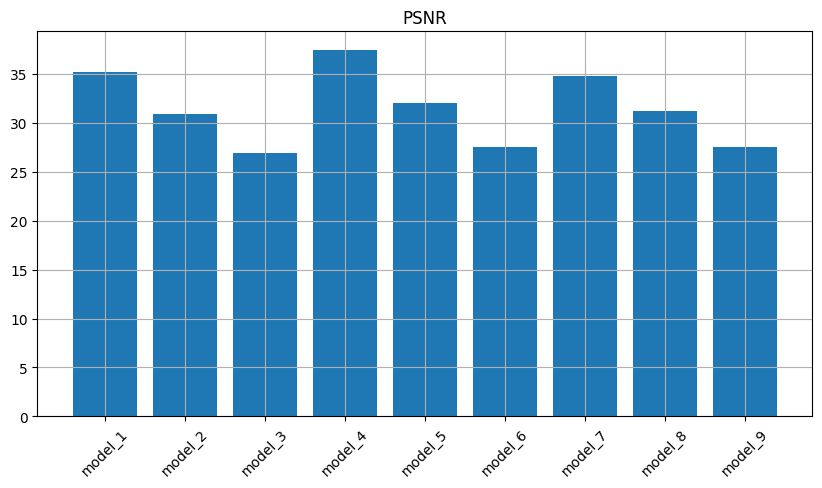

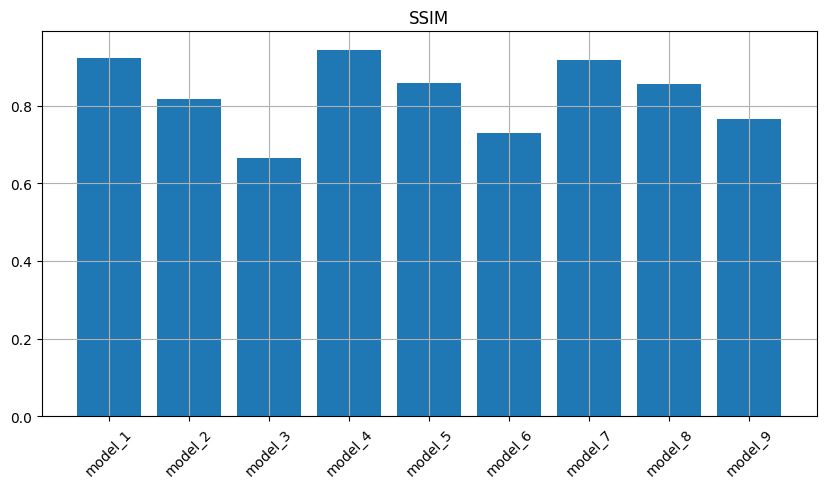

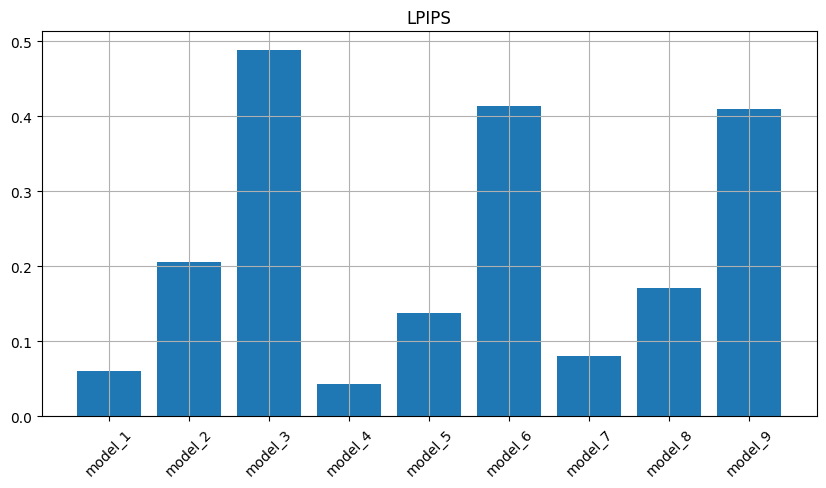

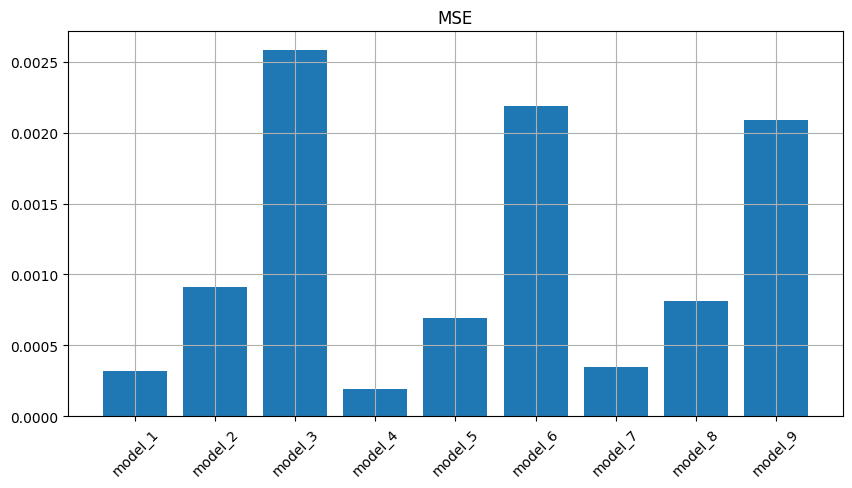

In [46]:
plot_metric(results, "psnr")
plot_metric(results, "ssim")
plot_metric(results, "lpips")
plot_metric(results, "mse")

In [67]:
import pandas as pd
from torch import sort

def results_to_table(results):
    rows = []

    for model_name, data in results.items():
        row = {
            "Model": model_name,
            "Scenario": data.get("scenario"),
            "Scale": data.get("scale"),
            "PSNR (dB)": data.get("psnr"),
            "SSIM": data.get("ssim"),
            "MSE": data.get("mse"),
            "LPIPS": data.get("lpips", None),  # por si no existe
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    # 🔥 ordenar por calidad (PSNR alto es mejor)
    df = df.sort_values(by="PSNR (dB)", ascending=False)

    return df
df_results = results_to_table(results)
df_results
df_results = df_results.sort_values(
    by="Model",
    key=lambda x: x.str.extract(r'(\d+)').astype(int)[0]
)

print(df_results)


     Model Scenario  Scale  PSNR (dB)      SSIM       MSE     LPIPS
0  model_1        A      2  35.192074  0.921983  0.000318  0.060069
1  model_2        A      4  30.840480  0.816731  0.000912  0.206436
2  model_3        A      8  26.933467  0.665588  0.002583  0.488676
3  model_4        B      2  37.434775  0.943971  0.000191  0.042924
4  model_5        B      4  32.007831  0.859550  0.000696  0.137890
5  model_6        B      8  27.490951  0.728514  0.002189  0.413544
6  model_7        C      2  34.787248  0.918248  0.000348  0.079948
7  model_8        C      4  31.195096  0.854696  0.000816  0.170854
8  model_9        C      8  27.515686  0.764962  0.002085  0.410010


In [49]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def show_sr_comparison(image_paths, EXPERIMENTS, index=0):
    """
    Muestra reconstrucción de todos los modelos para una imagen
    """

    # ─── Cargar imagen HR ─────────────────────────────
    img_path = image_paths[index]

    dataset_debug = SRDataset([img_path], EXPERIMENTS[0])
    lr, hr = dataset_debug[0]

    hr = hr.unsqueeze(0).to(DEVICE)
    lr = lr.unsqueeze(0).to(DEVICE)

    images_to_plot = []

    # HR
    images_to_plot.append(("HR", hr[0].cpu()))

    # LR (upsample solo para visualización)
    lr_up = F.interpolate(lr, size=hr.shape[-2:], mode='nearest')
    images_to_plot.append(("LR", lr_up[0].cpu()))

    # ─── Pasar por cada modelo ───────────────────────
    for cfg in EXPERIMENTS:
        try:
            generator = Generator(cfg.scale).to(DEVICE)

            ckpt_path = CHECKPOINTS_DIR / f"{cfg.name}.pth"

            if not ckpt_path.exists():
                print(f"❌ No existe {cfg.name}")
                continue

            ckpt = torch.load(ckpt_path, map_location=DEVICE)

            if "generator_state" in ckpt:
                generator.load_state_dict(ckpt["generator_state"])
            else:
                generator.load_state_dict(ckpt)

            generator.eval()

            with torch.no_grad():
                sr = generator(lr)

                # Ajustar tamaño si es necesario
                if sr.shape != hr.shape:
                    sr = F.interpolate(sr, size=hr.shape[-2:], mode='bilinear')

                sr = torch.clamp(sr, 0, 1)

            images_to_plot.append((cfg.name, sr[0].cpu()))

        except Exception as e:
            print(f"❌ Error en {cfg.name}: {e}")

    # ─── Plot ────────────────────────────────────────
    n = len(images_to_plot)
    plt.figure(figsize=(3*n, 4))

    for i, (title, img) in enumerate(images_to_plot):
        plt.subplot(1, n, i+1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

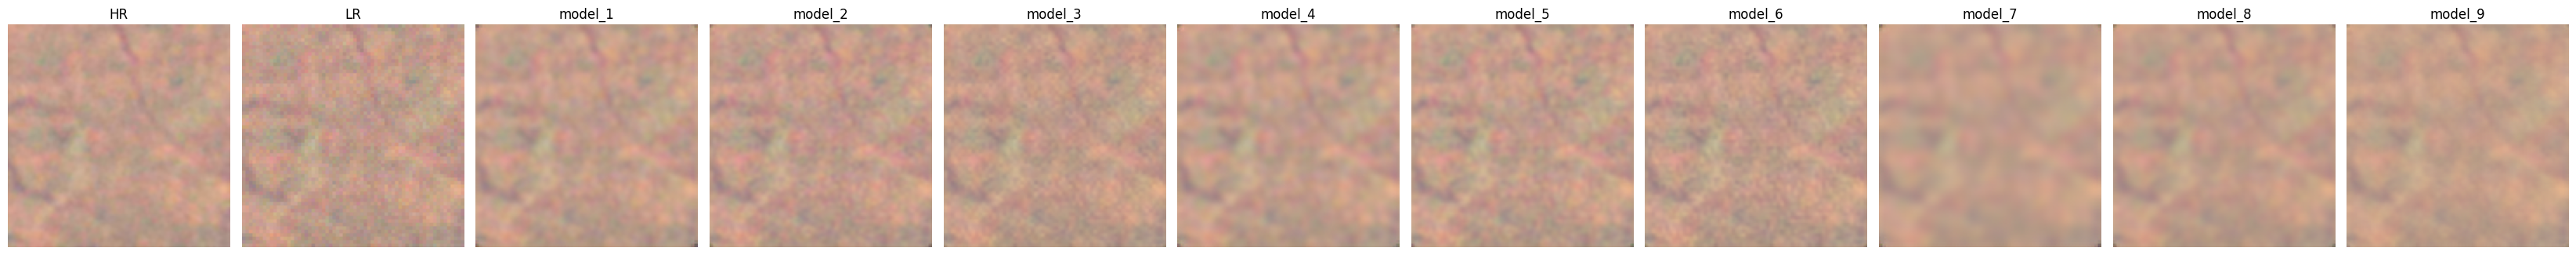

In [50]:
show_sr_comparison(image_paths, EXPERIMENTS, index=10)

In [53]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt
import math

def plot_grid(images, titles, cols=4):
    rows = math.ceil(len(images) / cols)

    plt.figure(figsize=(4*cols, 4*rows))

    for i in range(len(images)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title(titles[i], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
# ─── Transform base ─────────────────────────────
to_tensor = transforms.ToTensor()

# ─── Degradación (ajústala si ya tienes una función propia) ─────────────
def degrade_image(hr_img, cfg):
    """
    Genera imagen LR desde HR según configuración experimental
    """
    hr = hr_img.copy()

    # ─── Resize según escala ─────────────────────
    scale = cfg.scale
    w, h = hr.size

    lr_size = (w // scale, h // scale)

    if cfg.downsample == "bicubic":
        lr = hr.resize(lr_size, Image.BICUBIC)
    elif cfg.downsample == "bilinear":
        lr = hr.resize(lr_size, Image.BILINEAR)
    elif cfg.downsample == "lanczos":
        lr = hr.resize(lr_size, Image.LANCZOS)
    else:
        lr = hr.resize(lr_size)

    return lr


# ─── FUNCIÓN PRINCIPAL ───────────────────────────
def show_full_image_sr(image_path, EXPERIMENTS):
    # ─── Cargar imagen completa ───────────────────
    hr_pil = Image.open(image_path).convert("RGB")

    # ⚠️ opcional: limitar tamaño si es muy grande (evita morir)
    max_size = 1024
    if max(hr_pil.size) > max_size:
        hr_pil.thumbnail((max_size, max_size))

    hr = to_tensor(hr_pil).unsqueeze(0).to(DEVICE)

    images = []
    titles = []

    # ─── HR ───────────────────────────────────────
    images.append(hr[0].cpu())
    titles.append("HR (Original)")

    # ─── Para cada modelo ─────────────────────────
    for cfg in EXPERIMENTS:
        try:
            # 🔻 degradar imagen
            lr_pil = degrade_image(hr_pil, cfg)
            lr = to_tensor(lr_pil).unsqueeze(0).to(DEVICE)

            # 🔻 cargar modelo
            generator = Generator(cfg.scale).to(DEVICE)

            ckpt_path = CHECKPOINTS_DIR / f"{cfg.name}.pth"
            if not ckpt_path.exists():
                print(f"❌ No existe {cfg.name}")
                continue

            ckpt = torch.load(ckpt_path, map_location=DEVICE)

            if "generator_state" in ckpt:
                generator.load_state_dict(ckpt["generator_state"])
            else:
                generator.load_state_dict(ckpt)

            generator.eval()

            # 🔻 inferencia
            with torch.no_grad():
                sr = generator(lr)

                # ajustar tamaño
                if sr.shape != hr.shape:
                    sr = F.interpolate(sr, size=hr.shape[-2:], mode='bilinear')

                sr = torch.clamp(sr, 0, 1)

            images.append(sr[0].cpu())
            titles.append(cfg.name)

        except Exception as e:
            print(f"❌ Error en {cfg.name}: {e}")

    # ─── Plot grande ──────────────────────────────
    n = len(images)

    plt.figure(figsize=(4*n, 6))

    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plot_grid(images, titles, cols=4)
    plt.show()

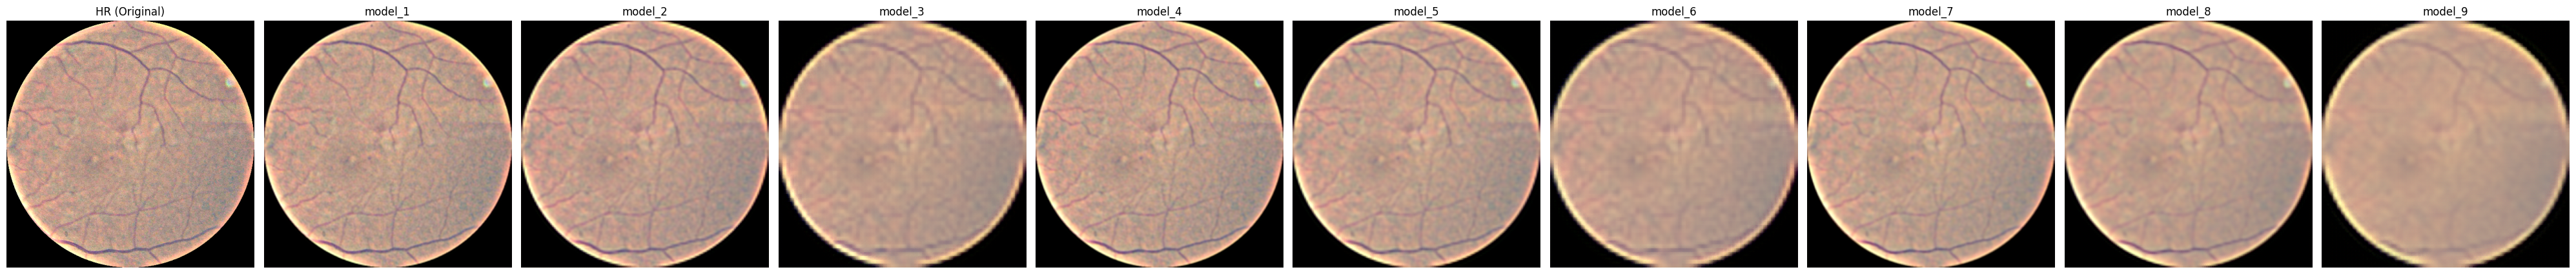

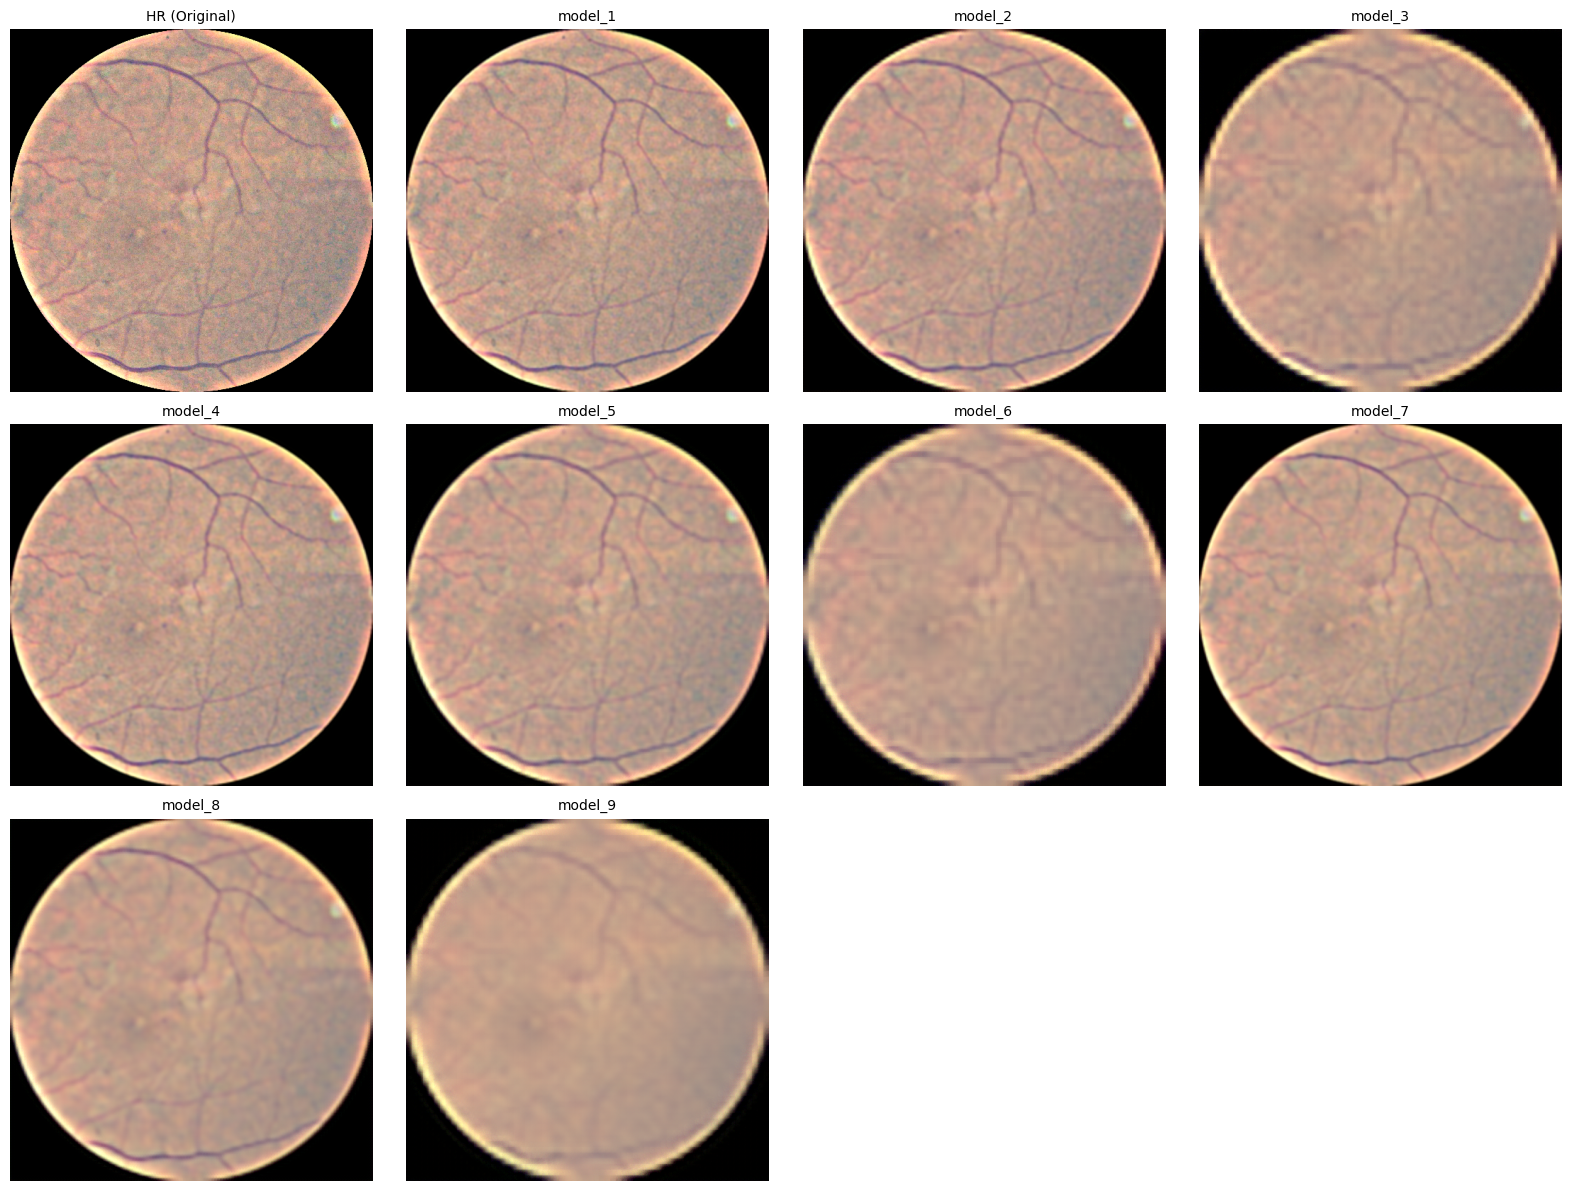

In [54]:
show_full_image_sr(
    image_paths[10],  # cualquier imagen real
    EXPERIMENTS
)

In [55]:
import matplotlib.pyplot as plt

def compare_single(hr, sr, model_name):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(hr)
    plt.title("HR (Original)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(sr)
    plt.title(model_name)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [56]:
def compare_all_models(hr, sr_dict):
    n = len(sr_dict)

    plt.figure(figsize=(10, 4*n))

    for i, (name, sr) in enumerate(sr_dict.items()):
        # HR
        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(hr)
        plt.title("HR")
        plt.axis("off")

        # SR
        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(sr)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [57]:
def zoom_comparison(hr, sr, x=200, y=200, size=100):
    hr_crop = hr[y:y+size, x:x+size]
    sr_crop = sr[y:y+size, x:x+size]

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(hr_crop)
    plt.title("HR (Zoom)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(sr_crop)
    plt.title("SR (Zoom)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()